In [222]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import MDS 

In [42]:
df = pd.read_pickle('results_with_slates_2.pkl')

In [44]:
df.head(2)

,filename,num_cands,num_voters,num_unique_ballots,avg_ballot_len,ballot_lengths,parties,method,block_size,silB,silH,centroids_H,centroids_B,medoids_H,medoids_B,slates
0,aberdeen_2017_ward12.csv,10,5598,1629,3.425688,"{0: 0, 1: 10, 2: 62, 3: 310, 4: 401, 5: 206, 6...","{1: 'Labour (Lab)', 2: 'Scottish National Part...",meanBC,0.416041,0.378763,0.379617,"{0: [-0.38170888793473595, 0.14340918849291542...","{0: [2.2915414340918847, 7.7075998282524685, 0...","{0: (2, 5), 1: (3,)}","{0: (2, 5), 1: (3, 1)}",None
1,aberdeen_2017_ward12.csv,10,5598,1629,3.425688,"{0: 0, 1: 10, 2: 62, 3: 310, 4: 401, 5: 206, 6...","{1: 'Labour (Lab)', 2: 'Scottish National Part...",meanBC,0.416041,0.378763,0.379617,"{0: [-0.38170888793473595, 0.14340918849291542...","{0: [2.2915414340918847, 7.7075998282524685, 0...","{0: (2, 5), 1: (3,)}","{0: (2, 5), 1: (3, 1)}",None


<Axes: xlabel='num_cands', ylabel='Count'>

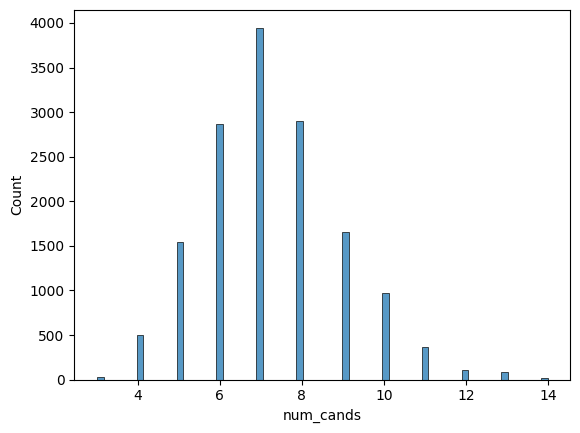

In [45]:
sns.histplot(df['num_cands'])

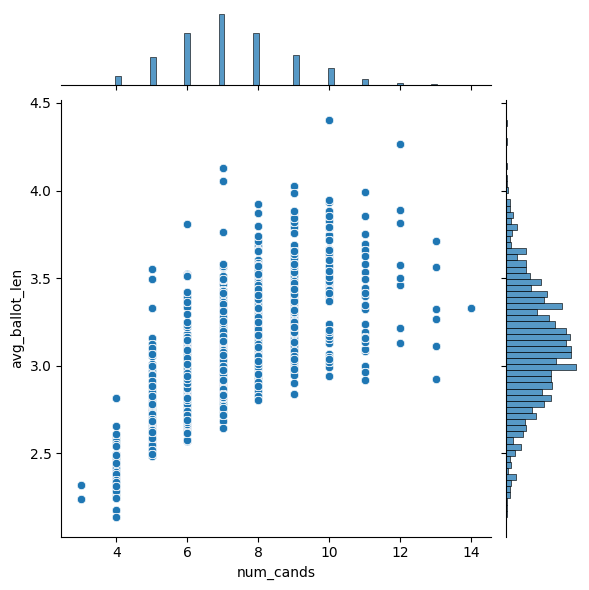

In [46]:
sns.jointplot(df, x='num_cands', y='avg_ballot_len')

In [47]:
ls = []
for row in range(len(df)):
    ls.append(min(df['block_size'][row],1-df['block_size'][row]))
df['bloc_size'] = ls

<Axes: xlabel='bloc_size', ylabel='Count'>

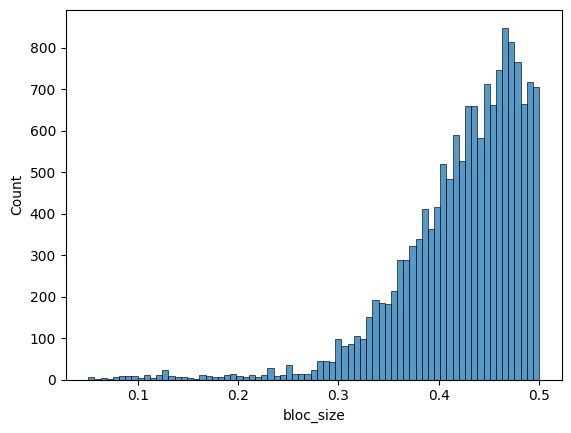

In [48]:

sns.histplot(data = df, x = 'bloc_size')

<Axes: xlabel='bloc_size', ylabel='method'>

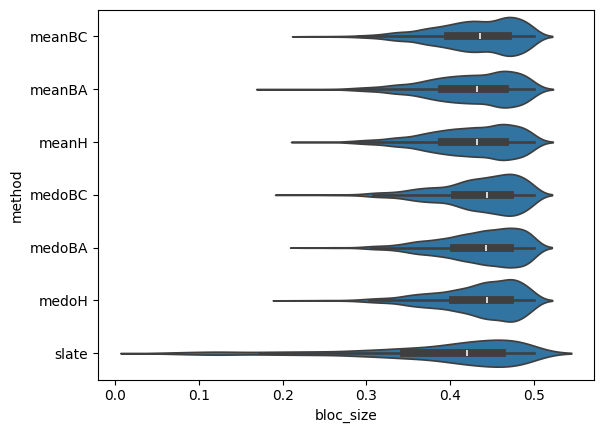

In [49]:
sns.violinplot(data = df, x = 'bloc_size', y='method')

<Axes: xlabel='num_voters', ylabel='Count'>

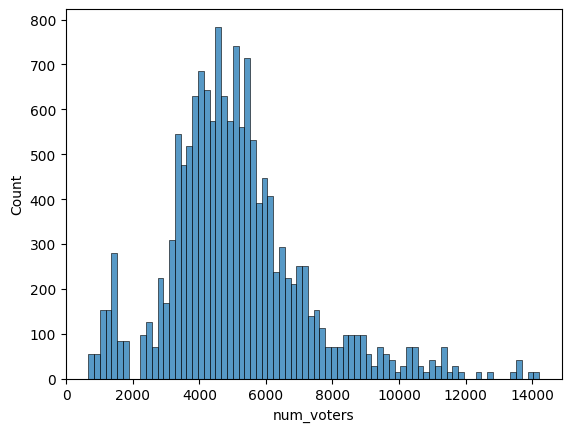

In [50]:
sns.histplot(data=df, x = 'num_voters')

In [51]:
ls = []
for count in range(len(df)):
    portion = df['ballot_lengths'][count][df['num_cands'][count]]/df['num_voters'][count]
    ls.append(portion)
df['portion_complete_ballots'] = ls

<Axes: xlabel='portion_complete_ballots', ylabel='Count'>

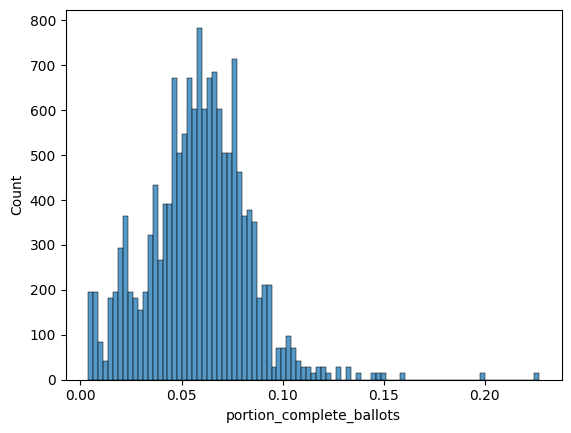

In [52]:
sns.histplot(data = df, x = 'portion_complete_ballots')

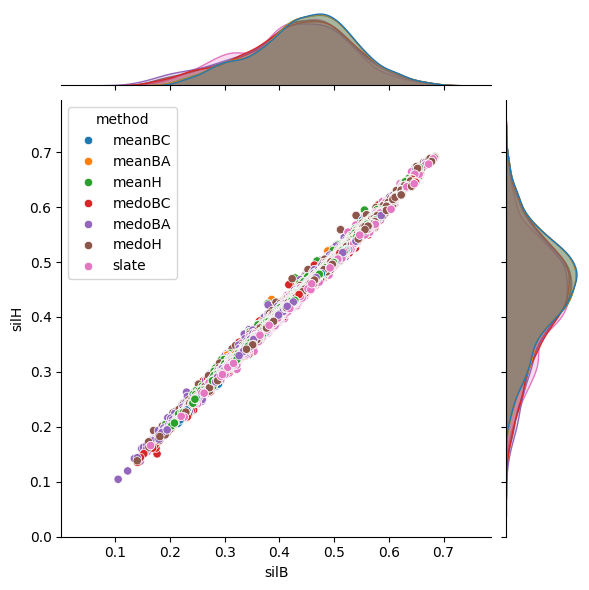

In [53]:
sns.jointplot(data=df, x='silB',y='silH', hue = 'method')

<Axes: xlabel='silB', ylabel='method'>

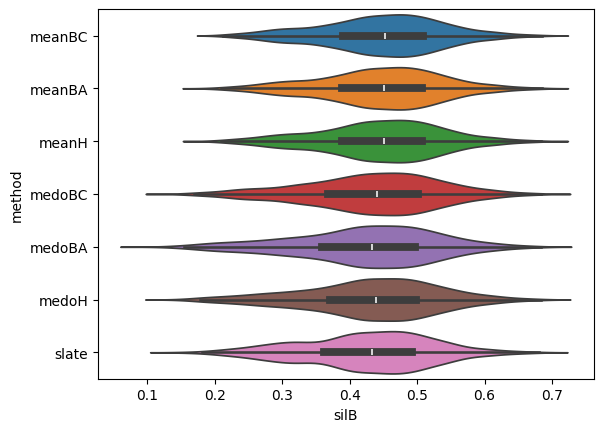

In [54]:
sns.violinplot(data=df, x = 'silB', y = 'method', hue = 'method')

In [148]:
# list of elections, list of clustering methods
filenames = (df['filename'].unique())
method_list = df['method'].unique()

In [149]:
# We ran each clustering method TWICE on each election.
# So we'll add a 'trial_num' column with entries {0,1}

df['trial_num'] = 0
for filename in filenames:
    for method in method_list:
        dfs = df[(df['filename']==filename) & (df['method'] == method)]
        indices = dfs.index # list of the two row numbers (indices) of dfs
        df['trial_num'][indices[1]]=1 # because 0 is already set to 0.


C:\Users\ktapp\AppData\Local\Temp\ipykernel_16628\2997412858.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trial_num'][indices[1]]=1 # because 0 is already set to 0.


In [57]:
# Euclidean distance between centroids (dictionaries), summed over the two partition pieces
# wrt the best match between the two pieces of the first clustering and of the second.

def Distance_between_centroids(C1,C2):
    d1 = np.linalg.norm(C1[0]-C2[0]) + np.linalg.norm(C1[1]-C2[1])
    d2 = np.linalg.norm(C1[0]-C2[1]) + np.linalg.norm(C1[1]-C2[0])
    return min(d1,d2)

In [72]:
# We ran each clustering method twice on each election.  How much do the two runs differ on average?
# Let's measure this by checking whether the centroids (and hense probably the clustyers) are identical

for method in method_list:
    print("\n")
    for proxy in ['centroids_B', 'centroids_H']:
        match_count = 0
        unmatch_count = 0
        summed_dif = 0
        for filename in filenames:
            dfs = df[(df['filename']==filename) & (df['method'] == method)]
            # print(method, indices)
            indices = dfs.index
            C1 = dfs[proxy][indices[0]]
            C2 = dfs[proxy][indices[1]]
            dist =  Distance_between_centroids(C1,C2)
            summed_dif += dist
            if dist == 0:
                match_count +=1
            else:
                unmatch_count +=1
            l = len(filenames)

        print(f"{method}-clustering with {proxy}-centroids: {round(match_count/l,4)} match \
              ({unmatch_count} disagreements), avg dist = {round(summed_dif/l,4)}")



meanBC-clustering with centroids_B-centroids: 0.9645 match               (38 disagreements), avg dist = 0.0011
meanBC-clustering with centroids_H-centroids: 0.9645 match               (38 disagreements), avg dist = 0.0003


meanBA-clustering with centroids_B-centroids: 0.9748 match               (27 disagreements), avg dist = 0.0008
meanBA-clustering with centroids_H-centroids: 0.9748 match               (27 disagreements), avg dist = 0.0002


meanH-clustering with centroids_B-centroids: 0.9729 match               (29 disagreements), avg dist = 0.0006
meanH-clustering with centroids_H-centroids: 0.9729 match               (29 disagreements), avg dist = 0.0002


medoBC-clustering with centroids_B-centroids: 0.914 match               (92 disagreements), avg dist = 0.3208
medoBC-clustering with centroids_H-centroids: 0.914 match               (92 disagreements), avg dist = 0.0851


medoBA-clustering with centroids_B-centroids: 0.9467 match               (57 disagreements), avg dist = 0.

In [100]:
# Next we'll compare different clustering methods differ
# with differences measured as the distance between their Borda-ceontriods.
# we'll gather the results in a 7-by-7 table

delta = pd.DataFrame(index = method_list, columns=method_list)

proxy = 'centroids_B'
for m1 in method_list:
    for m2 in method_list:
        #print(m1,m2)
        if m1==m2:
            i1,i2 = 0,1
        else:
            i1,i2 = 0,0
        summed_dist = 0
        for filename in filenames:
            dfs = df[(df['filename']==filename) & (df['method'] == m1)]
            indices = dfs.index
            C1 = dfs[proxy][indices[i1]]
            
            dfs = df[(df['filename']==filename) & (df['method'] == m2)]
            indices = dfs.index
            C2 = dfs[proxy][indices[i2]]           
        
            dist =  Distance_between_centroids(C1,C2)
            summed_dist += dist
        delta[m1][m2] = summed_dist/len(filenames)
            

In [101]:
delta

,meanBC,meanBA,meanH,medoBC,medoBA,medoH,slate
meanBC,0.001128,0.302144,0.330662,1.418977,1.575703,1.447049,2.110798
meanBA,0.302144,0.000767,0.074796,1.435545,1.559056,1.450227,2.169162
meanH,0.330662,0.074796,0.000585,1.436827,1.552451,1.44702,2.188802
medoBC,1.418977,1.435545,1.436827,0.320832,0.943898,0.700943,2.419342
medoBA,1.575703,1.559056,1.552451,0.943898,0.208062,0.886784,2.593173
medoH,1.447049,1.450227,1.44702,0.700943,0.886784,0.26805,2.521672
slate,2.110798,2.169162,2.188802,2.419342,2.593173,2.521672,0.0


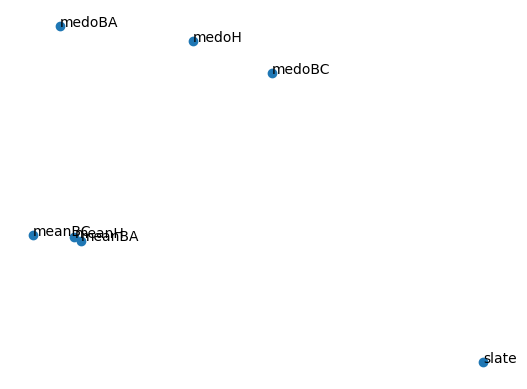

In [102]:
projections = MDS(n_components=2, dissimilarity='precomputed').fit_transform(delta)
X = np.array([p[0] for p in projections])
Y = np.array([p[1] for p in projections])
fig, ax = plt.subplots()
ax.scatter(X,Y)
for count in range(len(method_list)):
    ax.annotate(method_list[count], xy=(X[count], Y[count]))
ax.grid(False)
ax.axis('off')
plt.show()

In [143]:
# Next let's do it again with distance measured as the
# portion of elections in which the centroids are NOT exacty the same.

delta_same = pd.DataFrame(index = method_list, columns=method_list)

proxy = 'centroids_B'
for m1 in method_list:
    for m2 in method_list:
        #print(m1,m2)
        if m1==m2:
            i1,i2 = 0,1
        else:
            i1,i2 = 0,0
        dif_count = 0
        for filename in filenames:
            dfs = df[(df['filename']==filename) & (df['method'] == m1)]
            indices = dfs.index
            C1 = dfs[proxy][indices[i1]]
            
            dfs = df[(df['filename']==filename) & (df['method'] == m2)]
            indices = dfs.index
            C2 = dfs[proxy][indices[i2]]           
        
            dist =  Distance_between_centroids(C1,C2)
            if dist != 0:
                dif_count +=1
            
        delta_same[m1][m2] = dif_count/len(filenames)
delta_same
            

,meanBC,meanBA,meanH,medoBC,medoBA,medoH,slate
meanBC,0.035514,0.972897,0.976636,1.0,1.0,0.999065,0.998131
meanBA,0.972897,0.025234,0.88785,1.0,1.0,1.0,0.998131
meanH,0.976636,0.88785,0.027103,1.0,1.0,0.999065,0.998131
medoBC,1.0,1.0,1.0,0.085981,1.0,0.992523,0.999065
medoBA,1.0,1.0,1.0,1.0,0.053271,1.0,1.0
medoH,0.999065,1.0,0.999065,0.992523,1.0,0.064486,1.0
slate,0.998131,0.998131,0.998131,0.999065,1.0,1.0,0.0


In [151]:
# Next let's do it again with distance measured as the
# portion of elections in which the MEDOIDS are NOT exacty the same.

delta_same = pd.DataFrame(index = method_list, columns=method_list)

proxy = 'medoids_B'
for m1 in method_list:
    for m2 in method_list:
        #print(m1,m2)
        if m1==m2:
            i1,i2 = 0,1
        else:
            i1,i2 = 0,0
        dif_count = 0
        for filename in filenames:
            dfs = df[(df['filename']==filename) & (df['method'] == m1)]
            indices = dfs.index
            C1 = dfs[proxy][indices[i1]]
            
            dfs = df[(df['filename']==filename) & (df['method'] == m2)]
            indices = dfs.index
            C2 = dfs[proxy][indices[i2]]           
        
            if not ((C1[0]==C2[0] and C1[1]==C2[1]) or (C1[0]==C2[1] and C1[1]==C2[0])): 
                dif_count +=1
            
        delta_same[m1][m2] = dif_count/len(filenames)

In [152]:
delta_same

,meanBC,meanBA,meanH,medoBC,medoBA,medoH,slate
meanBC,0.0,0.092523,0.095327,0.271963,0.318692,0.281308,0.347664
meanBA,0.092523,0.000935,0.033645,0.283178,0.298131,0.278505,0.358879
meanH,0.095327,0.033645,0.0,0.285981,0.291589,0.273832,0.360748
medoBC,0.271963,0.283178,0.285981,0.085981,0.318692,0.250467,0.376636
medoBA,0.318692,0.298131,0.291589,0.318692,0.053271,0.280374,0.440187
medoH,0.281308,0.278505,0.273832,0.250467,0.280374,0.064486,0.407477
slate,0.347664,0.358879,0.360748,0.376636,0.440187,0.407477,0.0


In [110]:
df.columns

Index(['filename', 'num_cands', 'num_voters', 'num_unique_ballots',
       'avg_ballot_len', 'ballot_lengths', 'parties', 'method', 'block_size',
       'silB', 'silH', 'centroids_H', 'centroids_B', 'medoids_H', 'medoids_B',
       'slates', 'bloc_size', 'portion_complete_ballots'],
      dtype='object')

In [153]:
df0 = df[df['trial_num'] == 0]  # only the first trial of each method

In [154]:
sdf0 = df.dropna(subset = ['slates']) # only the slate trials

In [139]:
slates = sdf['slates'][12]
medoids = sdf['medoids_B'][12]
print(slates, medoids)

{0: (2, 5, 8), 1: (1, 3, 4, 6, 7, 9, 10)} {0: (2, 5), 1: (3, 1)}


In [147]:
set(medoids[0]).issubset(set(slates[0])) and set(medoids[1]).issubset(set(slates[1]))

True

In [167]:
def Party_code_and_fullname(input_string):
    # Find the start and end indices of the parentheses
    start_idx = input_string.find('(')
    end_idx = input_string.find(')')
    
    # If parentheses are found, extract the text inside them and the rest of the string
    if start_idx != -1 and end_idx != -1:
        A = input_string[start_idx + 1:end_idx]
        B = input_string[:start_idx].strip() + input_string[end_idx + 1:].strip()
        return A, B
    else:
        return None, input_string


In [181]:
# create a dictionary matching party codes to party full names
# (including all parties in all elections)

party_dict = dict()

for index in range(len(sdf0)):
    pdict = sdf0.iloc[index]['parties']
    for party in pdict.values():
        code,full_name = Party_code_and_fullname(party)
        # first check for codes associated to more than one full name.
        if code in party_dict.keys():
            if party_dict[code] != full_name:
                raise Exception(code, full_name, party_dict[code])
        else:
            party_dict[code] = full_name

In [195]:
# create a dictionary matching party codes to the total Borda points
# received by all candidates from that party in all elections
party_weights={code:0 for code in party_dict.keys()}

for rownum in range(len(sdf0)):
    pdict = sdf0.iloc[rownum]['parties']
    Borda_scores = sum(sdf0.iloc[rownum]['centroids_B'].values())
    for index in pdict.keys():
        code, full_name = Party_code_and_fullname(pdict[index])
        party_weights[code] += Borda_scores[index-1]

In [204]:
# scale the values to become percentage of all Borda points
total_weight = sum(party_weights.values())
for code, weight in party_weights.items():
    party_weights[code] = 100*weight/total_weight

In [209]:
def print_sorted(input_dict):
    # Sort the dictionary by values
    sorted_items = sorted(input_dict.items(), key=lambda item: item[1], reverse=True)
    
    # Print the sorted dictionary
    for key, value in sorted_items:
        print(f"{key}: {value}")

In [210]:
print_sorted(party_weights)

SNP: 29.190386894546933
Lab: 21.250387003806733
Ind: 16.09970268040258
Con: 13.251385558388069
LD: 8.844130032274014
Gr: 6.422960514973754
LabCo: 0.609907591259968
API: 0.5689466612022411
Soc: 0.4873079791400119
UKIP: 0.46038968603932623
TUSC: 0.3689088842585574
SFP: 0.35423192250237456
Sol: 0.33753573622645916
Glasgow First: 0.2048256848677165
SC: 0.177128117418337
SU: 0.17149254523194668
Libtn: 0.14771222702155867
SSC: 0.12030965873856637
Borders: 0.11366726904390034
SLP: 0.08495386575407388
IANL: 0.07807406696498478
ISP: 0.07145749224200967
WDuns: 0.06806906762379052
FA: 0.04044634002663774
Lib: 0.039623865203634416
OMG: 0.03784656043857012
NF: 0.03293166299613536
NRMUPB: 0.030313393240118426
EDIA: 0.030143492361948705
CICA: 0.02840408564240472
Rubbish: 0.02760137884550317
EKA: 0.027523634168763963
Pir: 0.026290145658137348
SDP: 0.023503295061818242
Sov: 0.021171692990409597
BNP: 0.020534212965752374
WEP: 0.020100731412213912
BP: 0.01946996636986034
CPA: 0.01430379617288116
Comm: 0.

In [220]:
top_parties = ['SNP', 'Lab', 'Ind', 'Con', 'LD', 'Gr']
scores = [party_weights[code] for code in top_parties]

In [221]:
top_parties.append('other')
scores.append(sum(x for x in party_weights.values() if x<=1))

([<matplotlib.patches.Wedge at 0x212edb004d0>,
 [Text(0.6689870254503651, 0.8731874711532871, 'SNP'),
  Text(-0.8823671578393454, 0.6568319410370631, 'Lab'),
  Text(-0.947145847370537, -0.5593878295143252, 'Ind'),
  Text(-0.12646491594449114, -1.0927061018568318, 'Con'),
  Text(0.6018397920466844, -0.9207545083838601, 'LD'),
  Text(0.9588145566902898, -0.5391425098049709, 'Gr'),
  Text(1.086774012358457, -0.17006541700857467, 'other')])

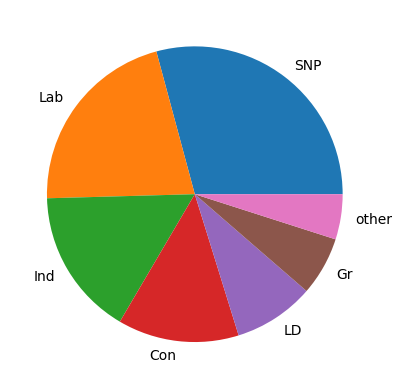

In [223]:
plt.pie(scores, labels = top_parties)